# Lab 6: OCR Evaluation & Metric Analysis

ประเมิน Tesseract OCR (`tha+eng`) บนชุดข้อมูล Transcript จาก Lab 5 จำนวน 282 ภาพที่มี Ground Truth

1. **Field Level**: CER และ Accuracy ของฟิลด์สำคัญ 8 ฟิลด์
2. **Page Level**: CER/WER ทั้งหน้า แยก original, augmented และชนิด augmentation
3. **Category Level**: เปรียบเทียบกลุ่มปริญญาตรี (`th`) กับบัณฑิตศึกษา (`G`)

## 1. ติดตั้งและ Import Libraries

In [2]:
%pip install pytesseract

Note: you may need to restart the kernel to use updated packages.


In [1]:
# รันบรรทัดนี้ครั้งแรกหากยังไม่มีไลบรารี
#%pip install pandas numpy pillow pytesseract matplotlib seaborn

import json, os, re, time, unicodedata
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image, ImageEnhance, ImageFilter, ImageOps
import pytesseract
import matplotlib.pyplot as plt
import seaborn as sns

# Windows: ปรับ path หากติดตั้ง Tesseract ไว้ที่อื่น
TESSERACT_EXE = Path(r'C:\Program Files\Tesseract-OCR\tesseract.exe')
if TESSERACT_EXE.exists():
    pytesseract.pytesseract.tesseract_cmd = str(TESSERACT_EXE)

DATASET_CANDIDATES = [
    Path('./Lab5_transcript_dataset'),
    Path('./Lab5_transcript_dataset-20260809T175322Z-1-001/Lab5_transcript_dataset'),
]
DATASET_DIR = next((p for p in DATASET_CANDIDATES if p.exists()), DATASET_CANDIDATES[0])
MANIFEST_FILE = DATASET_DIR / 'labels' / 'manifest.csv'
OUTPUT_DIR = Path('./lab6_results')
OUTPUT_DIR.mkdir(exist_ok=True)
print('Dataset:', DATASET_DIR.resolve())
print('Tesseract:', pytesseract.get_tesseract_version())

Dataset: C:\Users\User\Downloads\isd\Lab5_transcript_dataset-20260809T175322Z-1-001\Lab5_transcript_dataset
Tesseract: 5.5.3.20260724


## 2. ตรวจสอบ Dataset Manifest

In [2]:
manifest = pd.read_csv(MANIFEST_FILE)
manifest['gt_exists'] = manifest['gt_exists'].astype(str).str.lower().eq('true')
dataset_df = manifest[manifest['gt_exists']].copy().reset_index(drop=True)
print('Manifest records:', len(manifest))
print('Valid images with GT:', len(dataset_df))
display(dataset_df.groupby(['split', 'group']).size().rename('images').to_frame())

Manifest records: 288
Valid images with GT: 282


images
split     group        
augmented G         115
          th        120
original  G          23
          th         24

## 3. ฟังก์ชัน Metrics และ Ground Truth

In [3]:
EVAL_FIELDS = ['student_id', 'prename', 'name', 'faculty_name', 'degree', 'program', 'date_of_birth', 'admis_date']
CER_THRESHOLD = 0.20

def normalize_chars(value):
    text = unicodedata.normalize('NFKC', str(value or '')).casefold()
    return re.sub(r'\s+', '', text)

def normalize_words(value):
    text = unicodedata.normalize('NFKC', str(value or '')).casefold()
    return re.sub(r'\s+', ' ', text).strip()

def edit_distance(a, b):
    if len(a) < len(b): a, b = b, a
    previous = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        current = [i]
        for j, cb in enumerate(b, 1):
            current.append(min(current[-1] + 1, previous[j] + 1, previous[j-1] + (ca != cb)))
        previous = current
    return previous[-1]

def cer(reference, hypothesis):
    ref, hyp = normalize_chars(reference), normalize_chars(hypothesis)
    return edit_distance(ref, hyp) / max(1, len(ref))

def wer(reference, hypothesis):
    ref, hyp = normalize_words(reference).split(), normalize_words(hypothesis).split()
    return edit_distance(ref, hyp) / max(1, len(ref))

def best_substring_cer(target, full_text):
    target, text = normalize_chars(target), normalize_chars(full_text)
    if not target: return 0.0
    if target in text: return 0.0
    if not text: return 1.0
    width, stride = len(target), max(1, len(target) // 8)
    starts = list(range(0, max(1, len(text) - width + 1), stride))
    starts.append(max(0, len(text) - width))
    return min(1.0, min(cer(target, text[i:i+width]) for i in set(starts)))

def flatten_values(value):
    if isinstance(value, dict):
        return [x for v in value.values() for x in flatten_values(v)]
    if isinstance(value, list):
        return [x for v in value for x in flatten_values(v)]
    return [] if value is None else [str(value)]

def load_ground_truth(path):
    with open(path, encoding='utf-8-sig') as f: return json.load(f)

print('Evaluation functions ready')

Evaluation functions ready


## 4. รัน OCR ครบทุกภาพ

ผล OCR จะ cache ใน `lab6_results/ocr_cache.csv` เพื่อให้รอบถัดไปไม่ต้องรันใหม่ทั้งหมด

In [4]:
CACHE_FILE = OUTPUT_DIR / 'ocr_cache_enhanced.csv'
cache = {}
if CACHE_FILE.exists():
    old = pd.read_csv(CACHE_FILE).fillna('')
    cache = old.set_index('image_path').to_dict('index')

def prepare_variants(image):
    # Candidate 1: original; Candidate 2: upscale + contrast + sharpen
    rgb = image.convert('RGB')
    gray = ImageOps.grayscale(rgb)
    gray = ImageOps.autocontrast(gray, cutoff=1)
    gray = gray.resize((gray.width * 2, gray.height * 2), Image.Resampling.LANCZOS)
    enhanced = ImageEnhance.Contrast(gray).enhance(1.35).filter(ImageFilter.SHARPEN)
    return [('original_psm6', rgb, 6), ('enhanced_psm11', enhanced, 11)]

def run_candidate(image, psm):
    config = f'--oem 3 --psm {psm}'
    data = pytesseract.image_to_data(image, lang='tha+eng', config=config, output_type=pytesseract.Output.DICT)
    words, confs = [], []
    for word, conf in zip(data['text'], data['conf']):
        word = str(word).strip()
        try: confidence = float(conf)
        except (TypeError, ValueError): confidence = -1
        if word:
            words.append(word)
            if confidence >= 0: confs.append(confidence)
    text = ' '.join(words)
    # Confidence penalized when almost no text is detected
    quality = (float(np.mean(confs)) if confs else 0.0) * min(1.0, len(words) / 25)
    return text, quality

ocr_rows, started = [], time.time()
for i, row in dataset_df.iterrows():
    rel_path = row['image_path']
    field_text = None
    if rel_path in cache:
        cached = cache[rel_path]
        text = cached.get('ocr_text', '')
        field_text = cached.get('field_ocr_text', text)
        method = cached.get('selected_method', 'cached')
        confidence = cached.get('mean_confidence', np.nan)
    else:
        image = Image.open(DATASET_DIR / rel_path)
        candidates = []
        for method, variant, psm in prepare_variants(image):
            candidate_text, confidence = run_candidate(variant, psm)
            candidates.append((confidence, method, candidate_text))
        candidates.sort(reverse=True)
        confidence, method, text = candidates[0]
        # Union text improves field recall; page metrics use only best-confidence text
        field_text = ' '.join(item[2] for item in candidates)
    ocr_rows.append({'image_path': rel_path, 'ocr_text': text, 'field_ocr_text': field_text,
                     'selected_method': method, 'mean_confidence': confidence})
    if (i + 1) % 25 == 0 or i + 1 == len(dataset_df):
        print(f'Processed {i+1}/{len(dataset_df)} ({time.time()-started:.1f}s)')
ocr_df = pd.DataFrame(ocr_rows)
ocr_df.to_csv(CACHE_FILE, index=False, encoding='utf-8-sig')
print(f'Completed in {time.time()-started:.1f} seconds')

Processed 25/282 (67.2s)
Processed 50/282 (144.5s)
Processed 75/282 (209.1s)
Processed 100/282 (270.7s)
Processed 125/282 (323.7s)
Processed 150/282 (390.0s)
Processed 175/282 (444.7s)
Processed 200/282 (496.4s)
Processed 225/282 (550.2s)
Processed 250/282 (595.2s)
Processed 275/282 (646.6s)
Processed 282/282 (660.0s)
Completed in 660.1 seconds


## 5. คำนวณ Field, Page และ Category Metrics

In [6]:
records, field_records = [], []
ocr_map = dict(zip(ocr_df['image_path'], ocr_df['ocr_text']))
field_ocr_map = dict(zip(ocr_df['image_path'], ocr_df['field_ocr_text']))
for _, row in dataset_df.iterrows():
    gt = load_ground_truth(DATASET_DIR / row['gt_path'])
    header = gt.get('header_detail', {})
    ocr_text = ocr_map[row['image_path']]
    field_text = field_ocr_map[row['image_path']]
    field_cers = []
    for field in EVAL_FIELDS:
        score = best_substring_cer(header.get(field), field_text)
        field_cers.append(score)
        field_records.append({**row.to_dict(), 'field': field, 'cer': score, 'correct': score <= CER_THRESHOLD})
    reference_page = ' '.join(flatten_values(gt))
    records.append({**row.to_dict(), 'mean_field_cer': np.mean(field_cers),
                    'field_accuracy': np.mean(np.array(field_cers) <= CER_THRESHOLD),
                    'page_cer': cer(reference_page, ocr_text), 'page_wer': wer(reference_page, ocr_text)})
results = pd.DataFrame(records)
field_results = pd.DataFrame(field_records)
results.to_csv(OUTPUT_DIR / 'all_page_results.csv', index=False, encoding='utf-8-sig')
field_results.to_csv(OUTPUT_DIR / 'all_field_results.csv', index=False, encoding='utf-8-sig')
print('Metrics calculated:', len(results), 'pages')

Metrics calculated: 282 pages


## 6. Field Level Results

,mean_cer,accuracy_pct,count
field,,,
student_id,0.001,99.645,282
faculty_name,0.511,48.936,282
name,0.489,48.936,282
degree,0.511,48.936,282
prename,0.511,48.936,282
program,0.509,48.936,282
admis_date,0.579,0.000,282
date_of_birth,0.628,0.000,282


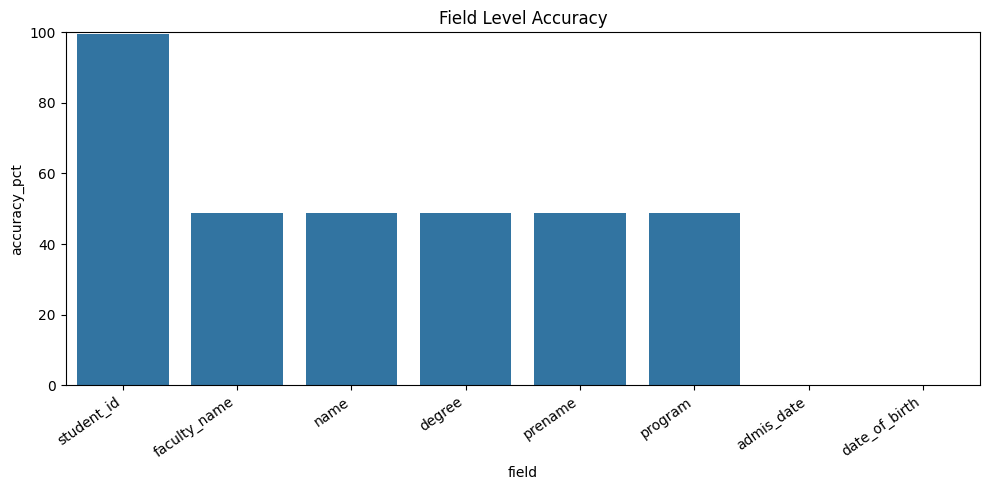

In [7]:
field_summary = field_results.groupby('field').agg(mean_cer=('cer','mean'), accuracy_pct=('correct','mean'), count=('correct','size'))
field_summary['accuracy_pct'] *= 100
field_summary = field_summary.sort_values('accuracy_pct', ascending=False).round(3)
display(field_summary)
plt.figure(figsize=(10,5)); sns.barplot(data=field_summary.reset_index(), x='field', y='accuracy_pct')
plt.xticks(rotation=35, ha='right'); plt.ylim(0,100); plt.title('Field Level Accuracy'); plt.tight_layout(); plt.show()

## 7. Page Level Results

Overall Page Level


,mean
page_cer,0.881
page_wer,1.778


Original vs Augmented


,page_cer,page_wer
split,,
augmented,0.879,1.773
original,0.890,1.803


By Augmentation Type


,page_cer,page_wer
aug_type,,
blur_contrast,0.830,1.714
jpeg_dark,0.886,1.756
noise,0.897,1.791
none,0.890,1.803
perspective,0.891,1.792
rotate_bright,0.888,1.812


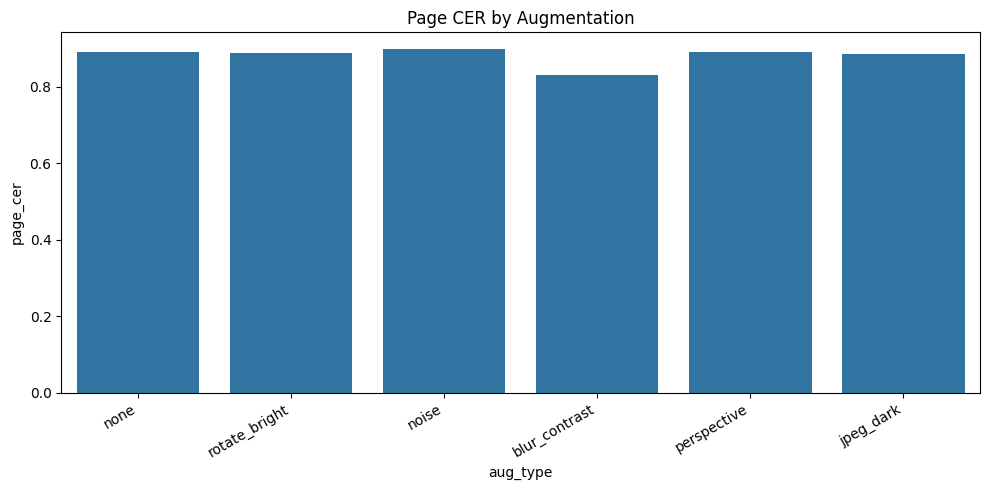

In [8]:
page_overall = results[['page_cer','page_wer']].mean().round(3)
page_by_split = results.groupby('split')[['page_cer','page_wer']].mean().round(3)
page_by_augtype = results.groupby('aug_type')[['page_cer','page_wer']].mean().round(3)
print('Overall Page Level'); display(page_overall.to_frame('mean'))
print('Original vs Augmented'); display(page_by_split)
print('By Augmentation Type'); display(page_by_augtype)
plt.figure(figsize=(10,5)); sns.barplot(data=results, x='aug_type', y='page_cer', errorbar=None)
plt.xticks(rotation=30, ha='right'); plt.title('Page CER by Augmentation'); plt.tight_layout(); plt.show()

## 8. Category Level Results

In [9]:
group_names = {'G':'G (บัณฑิตศึกษา)', 'th':'th (ป.ตรี)'}
category_summary = results.groupby('group').agg(mean_field_cer=('mean_field_cer','mean'), field_accuracy_pct=('field_accuracy','mean'), page_cer=('page_cer','mean'), page_wer=('page_wer','mean'))
category_summary['field_accuracy_pct'] *= 100
category_summary.index = category_summary.index.map(group_names)
category_summary = category_summary.round(3)
display(category_summary)
category_summary.to_csv(OUTPUT_DIR / 'category_summary.csv', encoding='utf-8-sig')

,mean_field_cer,field_accuracy_pct,page_cer,page_wer
group,,,,
G (บัณฑิตศึกษา),0.478,42.391,0.939,1.849
th (ป.ตรี),0.457,43.663,0.824,1.710
